# Signal-to-Noise Ratio (SNR) — 視覚的デモ

**SNR（信号対雑音比）** は、信号がバックグラウンドノイズに対してどれだけ際立っているかを表す指標です。

## 定義

$$\text{SNR}_{\text{dB}} = 10 \cdot \log_{10}\left(\frac{P_{\text{signal}}}{P_{\text{noise}}}\right)$$

ここで**電力**は平均二乗値として定義されます：

$$P = \overline{x^2} = \frac{1}{N}\sum_{i=1}^{N} x_i^2$$

## このノートブックの内容

1. クリーンな正弦波の参照信号を生成する  
2. 制御された SNR レベル（30, 20, 10, 0 dB）でガウスノイズを付加する  
3. **時間領域**と**周波数領域**の両方で効果を可視化する  
4. 測定 SNR が目標値と ±0.1 dB 以内で一致することを検証する  
5. *（オプション）* スライダーで任意の SNR を対話的に探索する

---
## 1 — セットアップ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

SAMPLE_RATE = 1000   # Hz
DURATION    = 1.0    # sec
SIGNAL_FREQ = 50     # Hz
SNR_LEVELS  = [30, 20, 10, 0]  # dB
RNG         = np.random.default_rng(42)

---
## 2 — 信号の生成

参照信号として**単一周波数の正弦波**を使う理由は、その電力が解析的に既知だからです：

$$P_{\sin} = \frac{A^2}{2}$$

単位振幅（$A = 1$）のとき電力はちょうど **0.5** となり、近似なしで必要なノイズ標準偏差を導出できます。

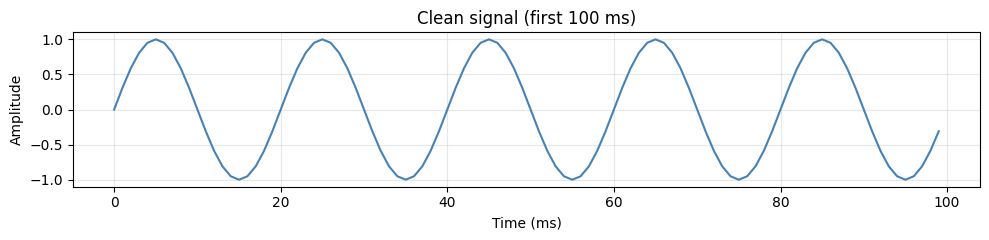

In [2]:
t = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION), endpoint=False)
signal = np.sin(2 * np.pi * SIGNAL_FREQ * t)

# Plot first 100 ms of the clean signal
mask = t < 0.1
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t[mask] * 1000, signal[mask], color='steelblue', lw=1.5)
ax.set(title='Clean signal (first 100 ms)',
       xlabel='Time (ms)', ylabel='Amplitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3 — ノイズの付加

### 目標 SNR からノイズ標準偏差を導出する

SNR の定義式から出発します：

$$\text{SNR}_{\text{dB}} = 10 \log_{10}\!\left(\frac{P_s}{P_n}\right)$$

$P_n$ について解くと：

$$P_n = \frac{P_s}{10^{\,\text{SNR}_{\text{dB}}/10}}$$

零平均ガウスノイズでは $P_n = \sigma^2$ なので：

$$\sigma = \sqrt{P_n}$$

以下の `add_noise` はこの式をそのまま実装しています。

In [3]:
def add_noise(signal, snr_db, rng):
    """Return (noisy_signal, noise) with the given SNR in dB."""
    p_signal = np.mean(signal**2)
    p_noise  = p_signal / (10 ** (snr_db / 10))
    sigma    = np.sqrt(p_noise)
    noise    = rng.normal(0, sigma, size=len(signal))
    return signal + noise, noise


noisy_signals = {}
noises        = {}
for snr in SNR_LEVELS:
    noisy_signals[snr], noises[snr] = add_noise(signal, snr, RNG)

print('Noise sigmas generated:')
for snr in SNR_LEVELS:
    sigma = np.std(noises[snr])
    print(f'  SNR {snr:3d} dB  →  σ_noise = {sigma:.4f}')

Noise sigmas generated:
  SNR  30 dB  →  σ_noise = 0.0221
  SNR  20 dB  →  σ_noise = 0.0717
  SNR  10 dB  →  σ_noise = 0.2272
  SNR   0 dB  →  σ_noise = 0.6900


---
## 4 — 時間領域の比較

各パネルは信号の先頭 **100 ms** を表示し、個々の波形サイクルを見やすくしています。  
カラーは青 → 緑 → オレンジ → 赤と変化し、SNR の低下を示します。

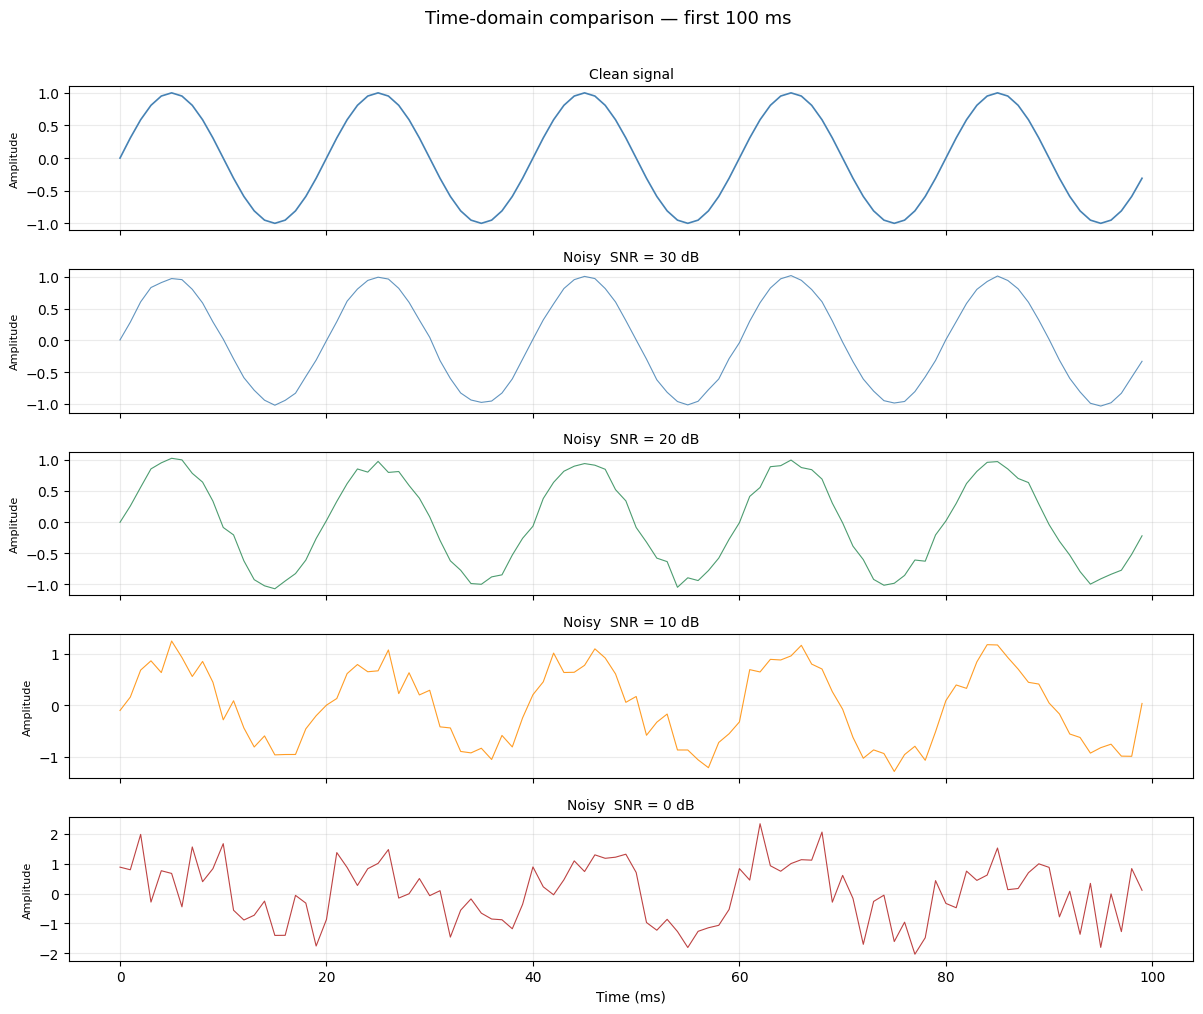

In [4]:
colors = ['steelblue', 'seagreen', 'darkorange', 'firebrick']
labels = [f'Noisy  SNR = {snr} dB' for snr in SNR_LEVELS]
mask   = t < 0.1

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

# Clean signal
axes[0].plot(t[mask] * 1000, signal[mask], color='steelblue', lw=1.2)
axes[0].set_title('Clean signal', fontsize=10)

# Noisy signals
for ax, snr, color, label in zip(axes[1:], SNR_LEVELS, colors, labels):
    ax.plot(t[mask] * 1000, noisy_signals[snr][mask], color=color, lw=0.8, alpha=0.85)
    ax.set_title(label, fontsize=10)

for ax in axes:
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Time-domain comparison — first 100 ms', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5 — 周波数領域（FFT）解析

FFT はノイズ**フロア**を明らかにします。白色雑音はエネルギーを全周波数に均等に広げる一方、信号は 50 Hz の単一スパイクに電力を集中させます。  
SNR が下がるとフロアが上昇し、やがてスパイクを飲み込みます。

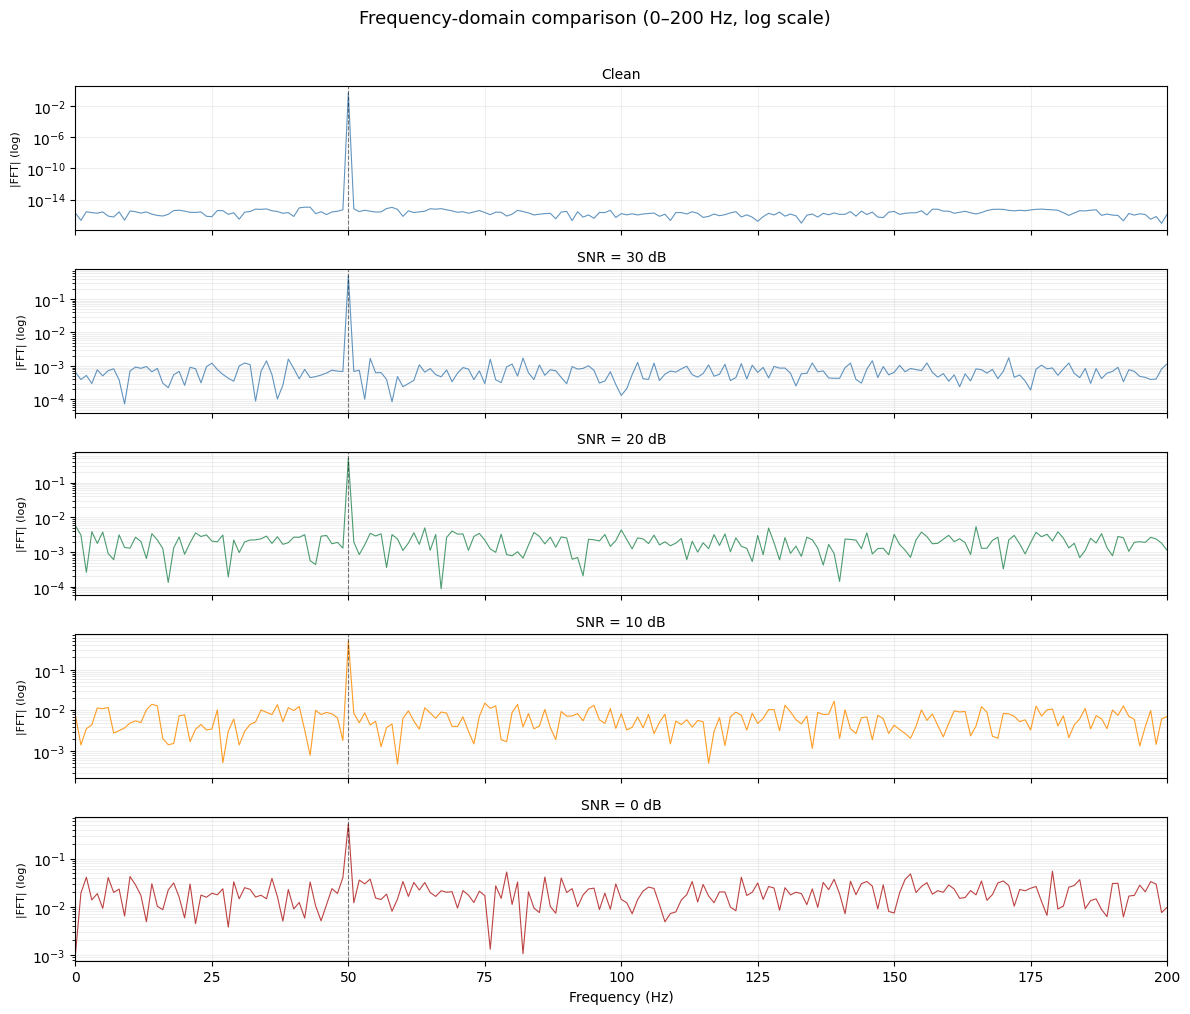

In [5]:
def compute_spectrum(x, sample_rate):
    freqs = np.fft.rfftfreq(len(x), d=1 / sample_rate)
    mags  = np.abs(np.fft.rfft(x)) / len(x)
    return freqs, mags


fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

all_signals = [('Clean', signal, 'steelblue')] + [
    (f'SNR = {snr} dB', noisy_signals[snr], c)
    for snr, c in zip(SNR_LEVELS, colors)
]

for ax, (label, sig, color) in zip(axes, all_signals):
    freqs, mags = compute_spectrum(sig, SAMPLE_RATE)
    ax.semilogy(freqs, mags, color=color, lw=0.8, alpha=0.85)
    ax.axvline(SIGNAL_FREQ, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlim(0, 200)
    ax.set_ylabel('|FFT| (log)', fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.grid(True, which='both', alpha=0.2)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Frequency-domain comparison (0–200 Hz, log scale)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 — SNR の検証

2 種類の測定方法で比較します：

* **方法 1 — 厳密法**: 保存したノイズ配列をそのまま使う  
  $\text{SNR} = 10 \log_{10}(P_s / P_n)$

* **方法 2 — 残差法**: ノイズ信号からクリーン信号を引いて推定する  
  $\hat{n} = x_{\text{noisy}} - x_{\text{clean}}$、次に $\text{SNR} = 10 \log_{10}(P_s / P_{\hat{n}})$  
  実務ではノイズ単体を取り出せないことが多いため、こちらの方が現実的な手法です。

In [6]:
p_signal = np.mean(signal**2)

print(f"{'Target dB':>10}  {'Measured (exact)':>18}  {'Measured (residual)':>20}")
print('-' * 54)

for snr in SNR_LEVELS:
    # Method 1: exact noise
    p_noise_exact   = np.mean(noises[snr]**2)
    measured_exact  = 10 * np.log10(p_signal / p_noise_exact)

    # Method 2: residual
    residual        = noisy_signals[snr] - signal
    p_noise_res     = np.mean(residual**2)
    measured_res    = 10 * np.log10(p_signal / p_noise_res)

    print(f"{snr:>10}  {measured_exact:>17.4f}  {measured_res:>19.4f}")

 Target dB    Measured (exact)   Measured (residual)
------------------------------------------------------
        30            30.0948              30.0948
        20            19.8511              19.8511
        10             9.8557               9.8557
         0             0.2122               0.2122


---
## 7 — まとめ

* **SNR は信号の明瞭さを定量化する**: SNR が高いほど信号が支配的、低いほどノイズが支配的。
* **30 dB** — ノイズはほぼ見えず、元の波形がほぼ完全に保たれる。
* **20 dB** — わずかなざらつきが現れるが、正弦波はまだ明確に識別できる。
* **10 dB** — 信号は認識可能だが、ノイズによる歪みが著しい。
* **0 dB** — 信号電力とノイズ電力が等しく、波形はほぼ判別不能。
* **FFT** は強力な診断ツール：時間領域でノイズだらけに見えても、50 Hz のスパイクが隠れた周期性を示し続ける。
* 両方の測定方法（厳密法・残差法）は数値精度の範囲で一致しており、ノイズ付加の計算式が正しいことを確認できる。

---
## 8 — オプション：インタラクティブスライダー

`ipywidgets` が必要です。  
インストール: `pip install ipywidgets`（クラシック Notebook の場合は追加で `jupyter nbextension enable --py widgetsnbextension`）

In [7]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    # Pre-build time axis and clean signal (already done above, but keep cell self-contained)
    _t      = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION), endpoint=False)
    _signal = np.sin(2 * np.pi * SIGNAL_FREQ * _t)
    _mask   = _t < 0.1
    _rng    = np.random.default_rng(0)  # separate RNG so slider is reproducible

    def plot_snr(snr_db=20):
        noisy, _ = add_noise(_signal, snr_db, np.random.default_rng(snr_db))
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))

        # Time domain
        ax1.plot(_t[_mask] * 1000, _signal[_mask], label='Clean', alpha=0.6)
        ax1.plot(_t[_mask] * 1000, noisy[_mask],   label=f'Noisy ({snr_db} dB)', alpha=0.8)
        ax1.set(title='Time domain (first 100 ms)', xlabel='Time (ms)', ylabel='Amplitude')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.25)

        # Frequency domain
        freqs_c, mags_c = compute_spectrum(_signal, SAMPLE_RATE)
        freqs_n, mags_n = compute_spectrum(noisy,   SAMPLE_RATE)
        ax2.semilogy(freqs_c, mags_c, label='Clean',                  alpha=0.6)
        ax2.semilogy(freqs_n, mags_n, label=f'Noisy ({snr_db} dB)',   alpha=0.8)
        ax2.axvline(SIGNAL_FREQ, color='black', lw=0.8, ls='--', alpha=0.5)
        ax2.set(title='Frequency domain (log)', xlabel='Frequency (Hz)', xlim=(0, 200))
        ax2.legend(fontsize=8)
        ax2.grid(True, which='both', alpha=0.2)

        plt.tight_layout()
        plt.show()

    interact(plot_snr, snr_db=widgets.IntSlider(min=0, max=40, step=1, value=20,
                                                description='SNR (dB)',
                                                continuous_update=False))

except ImportError:
    print('ipywidgets is not installed — skipping interactive slider.')
    print('Install with:  pip install ipywidgets')

interactive(children=(IntSlider(value=20, continuous_update=False, description='SNR (dB)', max=40), Output()),…